In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine


In [2]:
wine_raw = load_wine()
wine = pd.DataFrame(wine_raw.data, columns=wine_raw.feature_names)
wine['target'] = wine_raw.target
wine['target'] = wine['target'].map({0: 'class_0', 1: 'class_1', 2: 'class_2'})
del wine_raw
wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


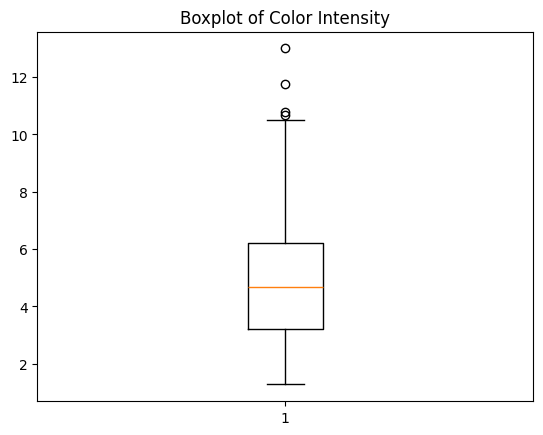

In [3]:
plt.boxplot(wine['color_intensity'])
plt.title('Boxplot of Color Intensity')
plt.show()

In [4]:
import numpy as np
def outliers_iqr(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data < lower_bound) | (data > upper_bound)]

outliers = outliers_iqr(wine["color_intensity"])
print(outliers)

151    10.80
158    13.00
159    11.75
166    10.68
Name: color_intensity, dtype: float64


In [5]:
print("이상치 인덱스:", outliers.index)
wine_no_outliers = wine.drop(index=outliers.index)
print("original data shape:", wine.shape)
print("data shape after removing outliers:", wine_no_outliers.shape)

이상치 인덱스: Index([151, 158, 159, 166], dtype='int64')
original data shape: (178, 14)
data shape after removing outliers: (174, 14)


In [6]:
wine.loc[outliers.index, "color_intensity"] = np.nan

wine['color_intensity']


0       5.64
1       4.38
2       5.68
3       7.80
4       4.32
       ...  
173     7.70
174     7.30
175    10.20
176     9.30
177     9.20
Name: color_intensity, Length: 178, dtype: float64

In [11]:
wine['color_intensity'] = wine['color_intensity'].fillna(wine['color_intensity'].mean())
wine.loc[outliers.index, "color_intensity"]

151    4.908678
158    4.908678
159    4.908678
166    4.908678
Name: color_intensity, dtype: float64